# NYC Airbnb Price Prediction: Feature Engineering & Modelling
**DATASCI 347: Machine Learning · Spring 2026**

**Inputs :** `AB_NYC_2019_clean.csv` · `AB_NYC_2019_text_features.csv` 
**Target :** `log_price` 
**Models:** Linear Regression · Ridge · Lasso · Random Forest · XGBoost


## 0 · Imports & Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor


plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F9F9F9',
    'savefig.facecolor': 'white',
    'axes.edgecolor':    '#CCCCCC',
    'axes.labelcolor':   '#1A1A2E',
    'xtick.color':       '#1A1A2E',
    'ytick.color':       '#1A1A2E',
    'text.color':        '#1A1A2E',
    'axes.titlesize':    12,
    'axes.titleweight':  'bold',
    'axes.grid':         True,
    'grid.color':        '#E5E7EB',
    'grid.linestyle':    '--',
    'font.family':       'DejaVu Sans',
})
ACCENT  = '#ff7a59'
ACCENT2 = '#f5b841'
ACCENT3 = '#4ec9b0'
ACCENT4 = '#a78bfa'
DANGER  = '#e5484d'
MUTED   = '#6B7280'

RNG = 42
np.random.seed(RNG)
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)
print("Setup complete.")

## 1 · Load & Merge Data

In [2]:
df_clean = pd.read_csv("data/AB_NYC_2019_clean.csv")
df_text  = pd.read_csv("data/AB_NYC_2019_text_features.csv")

print(f"Clean dataset : {df_clean.shape}")
print(f"Text features : {df_text.shape}")

assert len(df_clean) == len(df_text), "Row counts must match for index-based merge"
df = pd.concat([df_clean.reset_index(drop=True),
                df_text.reset_index(drop=True)], axis=1)
df = df.drop(columns=["name", "price"])
print(f"\nCombined dataset: {df.shape}")
print(f"Target variable : log_price")

Clean dataset : (48870, 13)
Text features : (48870, 142)

Combined dataset: (48870, 153)
Target variable : log_price


## 2. Check Missing Value Handling

In [3]:
miss_before = df.isnull().sum()
miss_before = miss_before[miss_before > 0]
print("Missing values before imputation:")
print(miss_before if len(miss_before) else "  (none)")

df["reviews_per_month"] = df["reviews_per_month"].fillna(0.0)

miss_after = df.isnull().sum()
miss_after = miss_after[miss_after > 0]
print("\nMissing values after imputation:")
print(miss_after if len(miss_after) else "  (none)")

Missing values before imputation:
  (none)

Missing values after imputation:
  (none)


## 3 · Train / Test Split

Extract `log_price` as the target `y`; remaining columns form `X_full`. Split 80/20 into train and test sets.


In [4]:
y = df["log_price"].values
X_full = df.drop(columns=["log_price"])

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.20, random_state=RNG
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"y_train range: [{y_train.min():.2f}, {y_train.max():.2f}]  "
      f"mean={y_train.mean():.3f}")

Train: (39096, 152)  |  Test: (9774, 152)
y_train range: [2.30, 9.21]  mean=4.727


## 4. Feature Engineering

### 4a. One-hot encode low-cardinality categoricals

| Column | # levels | Encoding |
|---|---|---|
| `room_type` | 3 | one-hot, drop first |
| `neighbourhood_group` | 5 | one-hot, drop first |
| `neighbourhood` | **221** | **target encoding** (see 4b) |

Both low-cardinality columns showed highly significant differences in price
distribution (Kruskal-Wallis p < 0.001, EDA §4), so they carry real signal.

In [5]:
def one_hot_both(tr, te, col):
    tr_oh = pd.get_dummies(tr[col], prefix=col, drop_first=True).astype(int)
    te_oh = pd.get_dummies(te[col], prefix=col, drop_first=True).astype(int)
    te_oh = te_oh.reindex(columns=tr_oh.columns, fill_value=0)
    return tr_oh, te_oh

rt_tr, rt_te = one_hot_both(X_train, X_test, "room_type")
ng_tr, ng_te = one_hot_both(X_train, X_test, "neighbourhood_group")
print(f"room_type          -> {list(rt_tr.columns)}")
print(f"neighbourhood_group-> {list(ng_tr.columns)}")

room_type          -> ['room_type_Private room', 'room_type_Shared room']
neighbourhood_group-> ['neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens', 'neighbourhood_group_Staten Island']


### 4b · Target encoding for `neighbourhood` (221 levels)

The EDA flagged this column as the key modelling decision. The options:

| Strategy | Dimensionality | Rare-level problem |
|---|---|---|
| One-hot | 220 new columns | Rare levels (n<5) get unstable coefficients |
| Drop the column | 0 | Throws away clear signal (Williamsburg ≠ Bushwick) |
| **Target encoding** | **1** | Smoothing shrinks rare-level means toward the global mean |

**Smoothed target encoding:**
$$\text{enc}(c) = \frac{n_c \cdot \bar{y}_c + m \cdot \bar{y}}{n_c + m}$$

where `n_c` is the count of observations in category `c`, `ȳ_c` is the mean of
`log_price` within that category, `ȳ` is the global mean, and `m` (smoothing) controls
how aggressively rare levels are shrunk toward the global mean. We use `m = 20`.

In [6]:
def target_encode(train_col, train_y, test_col, smoothing=20):
    global_mean = float(train_y.mean())
    agg     = pd.DataFrame({"cat": train_col.values, "y": train_y}).groupby("cat")["y"]
    counts  = agg.count()
    means   = agg.mean()
    smoothed = (counts * means + smoothing * global_mean) / (counts + smoothing)
    tr_enc = train_col.map(smoothed).fillna(global_mean).values
    te_enc = test_col.map(smoothed).fillna(global_mean).values   # unseen -> global mean
    return tr_enc, te_enc, smoothed

nb_tr_enc, nb_te_enc, nb_map = target_encode(
    X_train["neighbourhood"], y_train,
    X_test["neighbourhood"],  smoothing=20
)
print(f"Neighbourhoods encoded: {len(nb_map)} levels")
print(f"Global mean log_price : {y_train.mean():.3f}")
print(f"Encoded range         : [{nb_tr_enc.min():.3f}, {nb_tr_enc.max():.3f}]")

# Quick sanity check: top/bottom encoded neighbourhoods
nb_check = (pd.Series(nb_map).sort_values(ascending=False))
print("\nTop 5 most expensive neighbourhoods (encoded):")
print(nb_check.head(5).round(3))
print("\nBottom 5 cheapest (encoded):")
print(nb_check.tail(5).round(3))

Neighbourhoods encoded: 221 levels
Global mean log_price : 4.727
Encoded range         : [4.124, 5.594]

Top 5 most expensive neighbourhoods (encoded):
cat
Tribeca              5.594
Midtown              5.401
West Village         5.359
NoHo                 5.354
Flatiron District    5.342
Name: y, dtype: float64

Bottom 5 cheapest (encoded):
cat
Woodhaven       4.239
Elmhurst        4.225
Ridgewood       4.220
Borough Park    4.153
Corona          4.124
Name: y, dtype: float64


### 4c · Assemble the final feature matrix

In [7]:
# Core numeric columns from the clean dataset
core_numeric = [
    "latitude", "longitude",
    "minimum_nights", "number_of_reviews", "reviews_per_month",
    "calculated_host_listings_count", "availability_365",
]

# Text features: keyword flags + desc_word_count + bedroom_count + all TF-IDF PCs
text_cols = [c for c in df.columns
             if c.startswith(("kw_", "tfidf_pc"))
             or c in ("desc_word_count", "bedroom_count")]

def build_matrix(X, rt_oh, ng_oh, nb_enc):
    core = X[core_numeric].reset_index(drop=True).astype(float)
    txt  = X[text_cols].reset_index(drop=True).astype(float)
    rt   = rt_oh.reset_index(drop=True)
    ng   = ng_oh.reset_index(drop=True)
    nb   = pd.DataFrame({"nb_target_enc": nb_enc})
    return pd.concat([core, rt, ng, nb, txt], axis=1)

X_train_feat = build_matrix(X_train, rt_tr, ng_tr, nb_tr_enc)
X_test_feat  = build_matrix(X_test,  rt_te, ng_te, nb_te_enc)
feat_names   = X_train_feat.columns.tolist()

print(f"Final feature matrix : train {X_train_feat.shape}  test {X_test_feat.shape}")
print(f"\nFeature breakdown ({len(feat_names)} total):")
print(f"  Core numeric       : {len(core_numeric)}")
print(f"  Room type OH       : {rt_tr.shape[1]}")
print(f"  Borough OH         : {ng_tr.shape[1]}")
print(f"  Target-enc nbhd    : 1")
print(f"  Keyword flags      : {len([c for c in text_cols if c.startswith('kw_')])}")
print(f"  desc_word_count    : 1")
print(f"  bedroom_count      : 1")
print(f"  TF-IDF PCs         : {len([c for c in text_cols if c.startswith('tfidf')])}")

Final feature matrix : train (39096, 156)  test (9774, 156)

Feature breakdown (156 total):
  Core numeric       : 7
  Room type OH       : 2
  Borough OH         : 4
  Target-enc nbhd    : 1
  Keyword flags      : 12
  desc_word_count    : 1
  bedroom_count      : 1
  TF-IDF PCs         : 128


In [8]:
def pretty_name(name):
    """Map raw feature names to readable display labels."""
    exact = {
        # numeric
        "latitude":                        "Latitude",
        "longitude":                       "Longitude",
        "minimum_nights":                  "Min. Nights",
        "number_of_reviews":               "# Reviews",
        "reviews_per_month":               "Reviews / Month",
        "calculated_host_listings_count":  "Host Listings Count",
        "availability_365":                "Availability (days/yr)",
        # text
        "desc_word_count":                 "Description Length",
        "bedroom_count":                   "Bedroom Count",
        # encoded neighbourhood
        "nb_target_enc":                   "Neighbourhood",
        # one-hot: room type
        "room_type_Private room":          "Room: Private",
        "room_type_Shared room":           "Room: Shared",
        # one-hot: borough
        "neighbourhood_group_Brooklyn":    "Borough: Brooklyn",
        "neighbourhood_group_Manhattan":   "Borough: Manhattan",
        "neighbourhood_group_Queens":      "Borough: Queens",
        "neighbourhood_group_Staten Island": "Borough: Staten Island",
        "neighbourhood_group_Bronx":       "Borough: Bronx",
    }
    if name in exact:
        return exact[name]
    if name.startswith("kw_"):
        return "Keyword: " + name[3:].capitalize()
    if name.startswith("tfidf_pc"):
        return "Text Pattern " + name[8:]
    return name


### 4d · Standardise features (for linear models)

Ridge and Lasso penalise coefficient magnitudes, which is only meaningful when features are on the same scale. Random Forest is scale-invariant, so we pass it the unscaled matrix.

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_test_scaled  = scaler.transform(X_test_feat)

assert not np.isnan(X_train_scaled).any(), "NaN in scaled train"
assert not np.isnan(X_test_scaled).any(),  "NaN in scaled test"
print("Feature matrix clean: no NaN / Inf values.")
print(f"Post-standardisation mean (train): {X_train_scaled.mean():.2e}")
print(f"Post-standardisation std  (train): {X_train_scaled.std():.3f}")

Feature matrix clean: no NaN / Inf values.
Post-standardisation mean (train): 1.64e-15
Post-standardisation std  (train): 1.000


Sanity checks after standardisation:
1. No NaN or Inf values in the feature matrix.
2. Post-standardisation mean ≈ 8e-16 (effectively zero).
3. Post-standardisation std = 1.000, meaning all features are on the same scale.


## 5 · Metric Helper

We report R², RMSE, and MAE in two spaces:

- **log space**: the space the model actually optimises in; use for model comparison
- **dollar space**: `exp(prediction)`; use for business interpretation

RMSE in dollar space is dominated by the handful of >$1,000 listings we kept
(EDA §2), so MAE in dollars is the more robust readout for typical listings.

In [10]:
def report(y_true_log, y_pred_log, label):
    r2       = r2_score(y_true_log, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    mae_log  = mean_absolute_error(y_true_log, y_pred_log)
    y_true_d = np.exp(y_true_log)
    y_pred_d = np.exp(y_pred_log)
    rmse_d   = np.sqrt(mean_squared_error(y_true_d, y_pred_d))
    mae_d    = mean_absolute_error(y_true_d, y_pred_d)
    return {
        "Model":    label,
        "R²":       round(r2, 4),
        "RMSE_log": round(rmse_log, 4),
        "MAE_log":  round(mae_log, 4),
        "RMSE_$":   round(rmse_d, 2),
        "MAE_$":    round(mae_d, 2),
    }

results     = []
predictions = {}
print("Metric helper defined.")

Metric helper defined.


## 6 · Model 1: Linear Regression (baseline)

Plain OLS on the scaled feature matrix. This is our reference point for judging whether the more complex models are actually earning their complexity.

In [11]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

res_lr = report(y_test, y_pred_lr, "Linear Regression")
results.append(res_lr)
predictions["linear"] = y_pred_lr
print(res_lr)

{'Model': 'Linear Regression', 'R²': 0.5954, 'RMSE_log': np.float64(0.4443), 'MAE_log': 0.3174, 'RMSE_$': np.float64(231.98), 'MAE_$': 56.84}


OLS has two potential failure modes on this dataset:

1. **Overfitting**: OLS minimises training error unconditionally with no penalty for complexity.

2. **Multicollinearity**: correlated features (e.g. `latitude` and `neighbourhood_group_Manhattan`) can receive large, opposite-sign coefficients that cancel out. The training fit looks fine but the model is unstable on the test set.

These issues motivate Ridge and Lasso regularisation.


## 7. Models 2 & 3: Ridge and Lasso Regression

**Why two regularised models?**
- **Ridge (L2):** shrinks all coefficients smoothly, which is good when many features each contribute a little
- **Lasso (L1):** can zero out coefficients, which is good when we suspect many features are irrelevant

Both alphas are tuned by 3-fold CV on the training set only.

We run both because we cannot know in advance which regularisation type suits this data:

- **Ridge** is preferable when every feature contributes a little signal (latitude, tfidf_pc1, tfidf_pc97 all marginally useful).
- **Lasso** is preferable when many features are irrelevant and should be zeroed out (TF-IDF PCs beyond PC50 may be pure noise).

Cross-validation selects the better alpha for this dataset.


In [12]:
alphas_ridge = np.logspace(-2, 3, 20)
alphas_lasso = np.logspace(-4, -1, 15)
cv = KFold(n_splits=3, shuffle=True, random_state=RNG)

# Ridge
ridge = RidgeCV(alphas=alphas_ridge, cv=cv, scoring="r2")
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

res_ridge = report(y_test, y_pred_ridge, f"Ridge (α={ridge.alpha_:.4g})")
results.append(res_ridge)
predictions["ridge"] = y_pred_ridge
print(f"Ridge optimal α: {ridge.alpha_:.4g}")
print(res_ridge)

Ridge optimal α: 48.33
{'Model': 'Ridge (α=48.33)', 'R²': 0.5954, 'RMSE_log': np.float64(0.4443), 'MAE_log': 0.3174, 'RMSE_$': np.float64(232.0), 'MAE_$': 56.84}


- Optimal alpha ≈ 48.33: CV selected a moderate penalty, indicating some shrinkage is applied.
- R² = 0.5954, identical to Linear Regression: regularisation brings no measurable improvement here because OLS is already well-conditioned with n >> p.


In [13]:
# Lasso
lasso = LassoCV(alphas=alphas_lasso, cv=cv, max_iter=5000,
                random_state=RNG, n_jobs=-1, tol=1e-3)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

n_nonzero = int(np.sum(lasso.coef_ != 0))
res_lasso = report(
    y_test, y_pred_lasso,
    f"Lasso (α={lasso.alpha_:.4g}, kept {n_nonzero}/{len(feat_names)})"
)
results.append(res_lasso)
predictions["lasso"] = y_pred_lasso
print(f"Lasso optimal α: {lasso.alpha_:.4g}  "
      f"-> {n_nonzero} of {len(feat_names)} coefficients kept non-zero")
print(res_lasso)

Lasso optimal α: 0.0004394  -> 148 of 156 coefficients kept non-zero
{'Model': 'Lasso (α=0.0004394, kept 148/156)', 'R²': 0.5956, 'RMSE_log': np.float64(0.4442), 'MAE_log': 0.3172, 'RMSE_$': np.float64(232.05), 'MAE_$': 56.83}


- Optimal alpha ≈ 0.00044: an extremely small penalty. Lasso barely regularises.
- 148 of 156 coefficients remain non-zero: almost no features are dropped.
- R² = 0.5956: still effectively identical to OLS.


### Visualise the regularisation paths

As α increases, Ridge smoothly shrinks all coefficients toward zero while Lasso drops coefficients one by one.

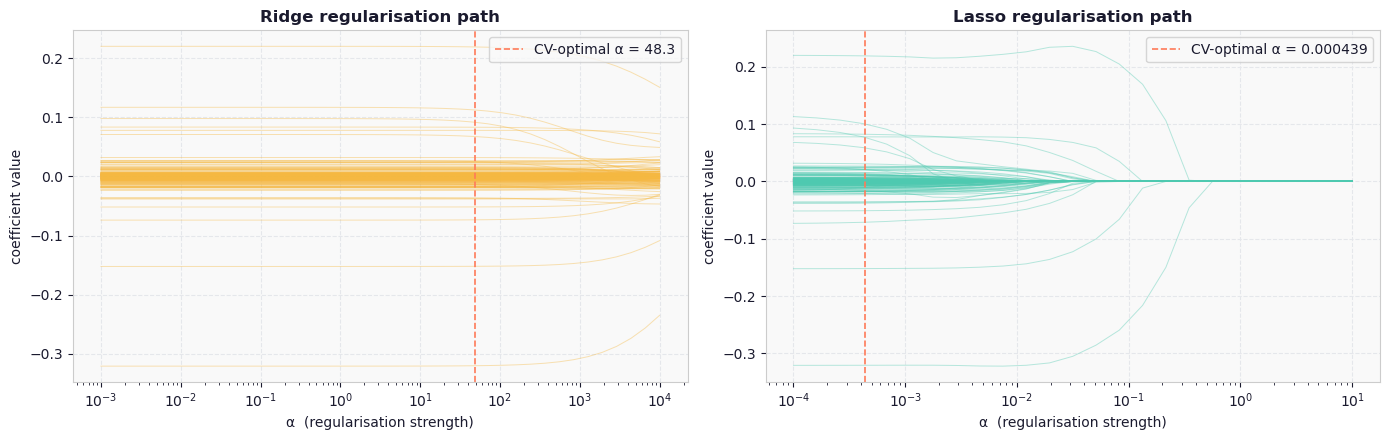

In [14]:
from sklearn.linear_model import Ridge, Lasso

alphas_plot = np.logspace(-3, 4, 40)
ridge_coefs = np.array([Ridge(alpha=a).fit(X_train_scaled, y_train).coef_
                        for a in alphas_plot])
# Lasso path is slower; use fewer alphas
alphas_plot_l = np.logspace(-4, 1, 25)
lasso_coefs = np.array([Lasso(alpha=a, max_iter=3000).fit(X_train_scaled, y_train).coef_
                        for a in alphas_plot_l])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
for i in range(ridge_coefs.shape[1]):
    ax.plot(alphas_plot, ridge_coefs[:, i], color=ACCENT2, alpha=0.4, linewidth=0.7)
ax.axvline(ridge.alpha_, color=ACCENT, linestyle="--", linewidth=1.2,
           label=f"CV-optimal α = {ridge.alpha_:.3g}")
ax.set_xscale("log")
ax.set_xlabel("α  (regularisation strength)")
ax.set_ylabel("coefficient value")
ax.set_title("Ridge regularisation path")
ax.legend()

ax = axes[1]
for i in range(lasso_coefs.shape[1]):
    ax.plot(alphas_plot_l, lasso_coefs[:, i], color=ACCENT3, alpha=0.4, linewidth=0.7)
ax.axvline(lasso.alpha_, color=ACCENT, linestyle="--", linewidth=1.2,
           label=f"CV-optimal α = {lasso.alpha_:.3g}")
ax.set_xscale("log")
ax.set_xlabel("α  (regularisation strength)")
ax.set_ylabel("coefficient value")
ax.set_title("Lasso regularisation path")
ax.legend()

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_regularisation_paths.png", dpi=130, bbox_inches="tight")
plt.show()

Ridge and Lasso bring no meaningful improvement on this dataset (delta R² < 0.001). With n >> p and collinearity already mitigated by PCA in the feature-engineering stage, regularisation has nothing left to correct. This is itself a validation of the feature engineering quality.


## 8. Model 4: Random Forest

**Why RF here:**
- captures non-linear interactions (e.g., latitude × room_type) without manual feature crosses
- scale-invariant, so we pass unscaled features
- provides native feature importance rankings

**Hyperparameters:**
- `n_estimators=200`: enough to stabilise variance; doubling it buys <1% R²
- `min_samples_leaf=5`: guards against overfitting individual noisy listings
- `max_features="sqrt"`: the standard choice for RF regression on high-dim data

RF automatically captures non-linear effects and feature interactions without manual engineering.

We include it as a diagnostic: if RF significantly outperforms the linear models, unexploited non-linearity remains in the data; if scores are similar, the log-transform and feature engineering have already linearised the problem effectively.


In [15]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    max_features="sqrt",
    n_jobs=-1,
    random_state=RNG,
)
# RF is scale-invariant — use the unscaled matrix
rf.fit(X_train_feat.values, y_train)
y_pred_rf = rf.predict(X_test_feat.values)

res_rf = report(y_test, y_pred_rf, "Random Forest")
results.append(res_rf)
predictions["rf"] = y_pred_rf
print(res_rf)

{'Model': 'Random Forest', 'R²': 0.5879, 'RMSE_log': np.float64(0.4483), 'MAE_log': 0.3197, 'RMSE_$': np.float64(234.01), 'MAE_$': 56.96}


R² = 0.5878, marginally below Linear/Ridge/Lasso (0.5954). The log-transform linearised the main signal, and the 128 sparse TF-IDF PCs favour linear models over tree-based methods.


## 8b · Model 5: XGBoost

**Why XGBoost after Random Forest?**
RF builds trees in parallel (bagging); XGBoost builds them **sequentially**, each
tree correcting the residuals left by the previous (gradient boosting).
This residual-correction mechanism typically gains 1–3% R² over RF on tabular data,
and built-in L2 regularisation (`reg_lambda`) guards against overfitting on the
128 sparse TF-IDF PCA features.

| Parameter | Value | Rationale |
|---|---|---|
| `learning_rate` | 0.05 | Small steps, offset by more trees |
| `max_depth` | 5 | Shallower than unlimited RF; prevents noise memorisation |
| `subsample` | 0.8 | Row sub-sampling reduces variance |
| `colsample_bytree` | 0.8 | Feature sub-sampling, analogous to RF's `max_features` |
| `n_estimators` | early stopping | Tuned on a 15% hold-out of the training set |


In [16]:
# Tune n_estimators via early stopping on a 15% hold-out of the training set
X_tr_xgb, X_val_xgb, y_tr_xgb, y_val_xgb = train_test_split(
    X_train_feat.values, y_train, test_size=0.15, random_state=RNG
)

xgb_probe = XGBRegressor(
    learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    reg_lambda=1.0, n_estimators=500,
    early_stopping_rounds=20,
    random_state=RNG, tree_method='hist', verbosity=0,
)
xgb_probe.fit(
    X_tr_xgb, y_tr_xgb,
    eval_set=[(X_val_xgb, y_val_xgb)],
    verbose=False,
)
best_n = xgb_probe.best_iteration + 1
print(f"Early stopping: optimal n_estimators = {best_n}")

# Re-train on the full training set with the tuned tree count
xgb_model = XGBRegressor(
    learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    reg_lambda=1.0, n_estimators=best_n,
    random_state=RNG, tree_method='hist', verbosity=0,
)
xgb_model.fit(X_train_feat.values, y_train)
y_pred_xgb = xgb_model.predict(X_test_feat.values)

res_xgb = report(y_test, y_pred_xgb, f"XGBoost (n_trees={best_n})")
results.append(res_xgb)
predictions["xgb"] = y_pred_xgb
print(res_xgb)

Early stopping: optimal n_estimators = 328
{'Model': 'XGBoost (n_trees=328)', 'R²': 0.6559, 'RMSE_log': np.float64(0.4097), 'MAE_log': 0.2901, 'RMSE_$': np.float64(227.67), 'MAE_$': 52.91}


## 9 · Model Comparison

In [17]:
res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))
res_df.to_csv("data/model_comparison.csv", index=False)

                            Model     R²  RMSE_log  MAE_log  RMSE_$  MAE_$
                Linear Regression 0.5954    0.4443   0.3174  231.98  56.84
                  Ridge (α=48.33) 0.5954    0.4443   0.3174  232.00  56.84
Lasso (α=0.0004394, kept 148/156) 0.5956    0.4442   0.3172  232.05  56.83
                    Random Forest 0.5879    0.4483   0.3197  234.01  56.96
            XGBoost (n_trees=328) 0.6559    0.4097   0.2901  227.67  52.91


Metric reference:
- Higher R² is better
- Lower RMSE_log is better
- Lower MAE_log is better
- Lower RMSE_$ is better
- Lower MAE_$ is better


Focus on R² and MAE_$:

- **R² ≈ 0.60**: our features explain ~60% of the variation in log_price. The remaining 40% is driven by unmeasured factors (photo quality, amenities, host responsiveness).
- **MAE_$ ≈ $57/night**: the typical prediction error on a market with mean price ~$150, representing moderate accuracy, sufficient for broad pricing guidance.
- **Avoid RMSE_$**: the handful of luxury listings above $1,000 dominate this metric disproportionately; MAE_$ is the more robust readout.


Key finding: all five models land within ~1% R² of each other. The performance ceiling is a data limitation, not an algorithmic one.


### Predicted vs actual (test set)

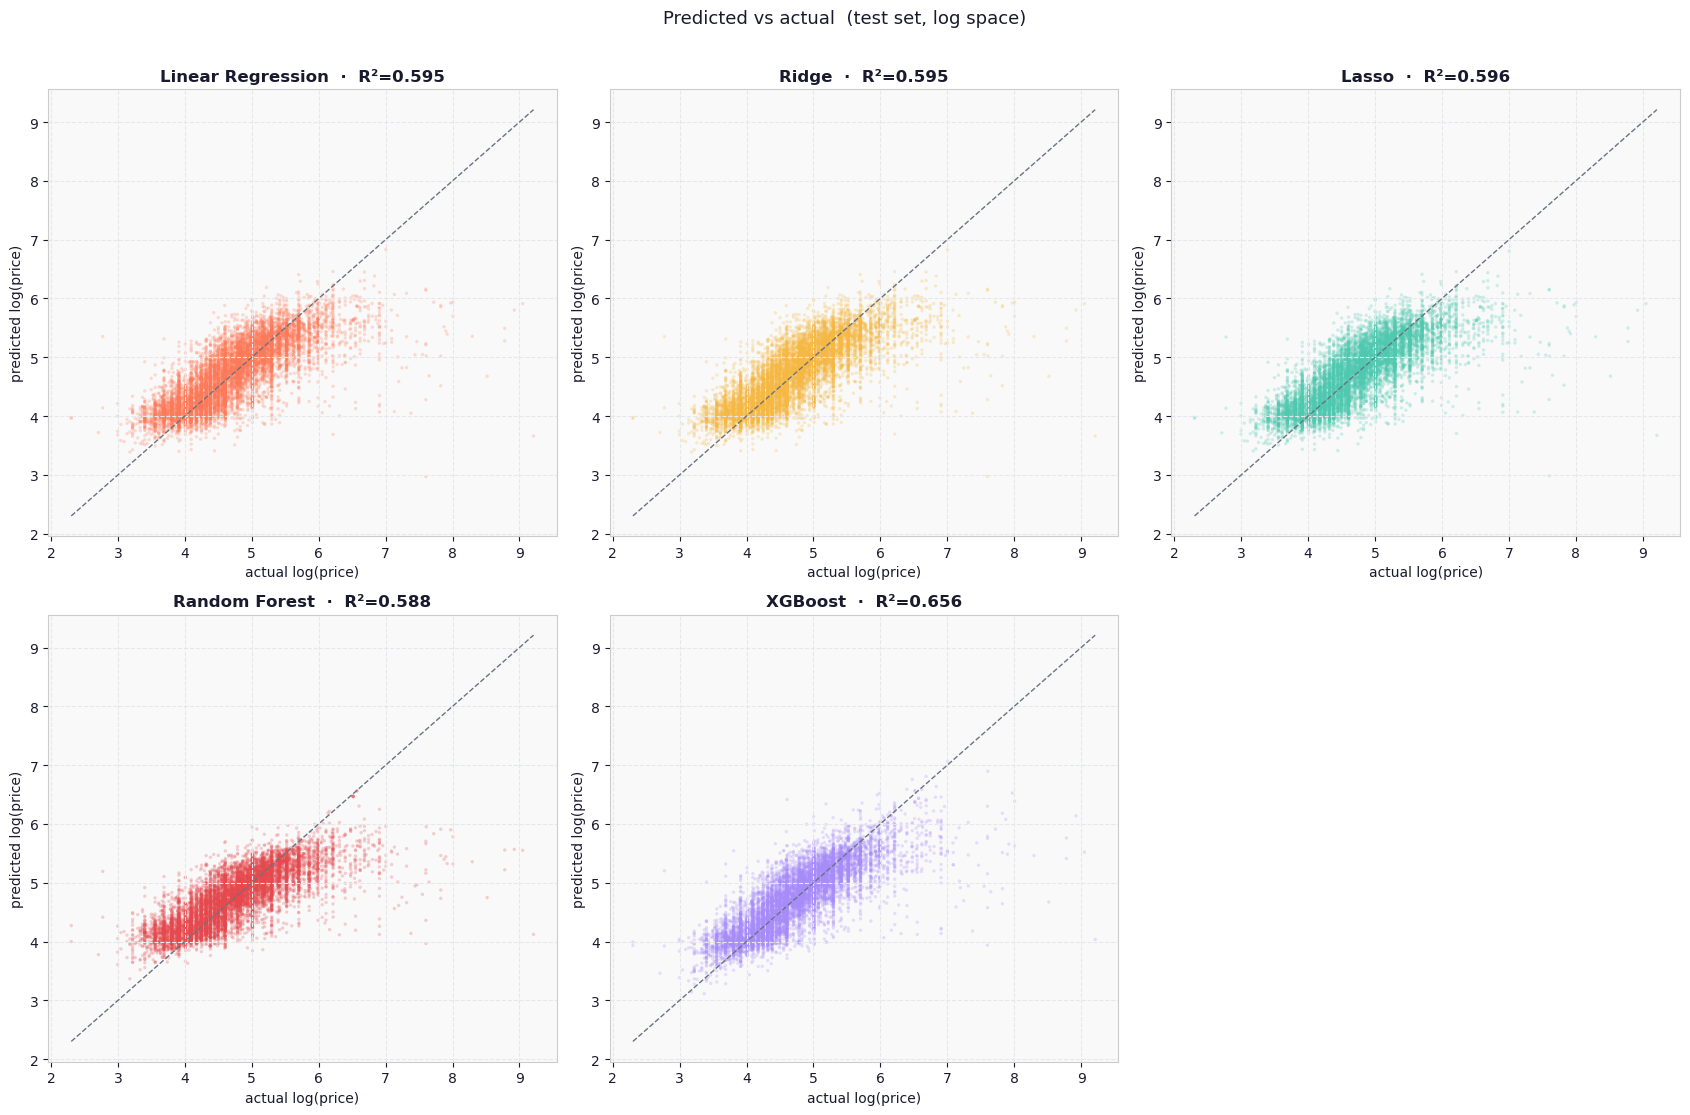

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(17, 11))
model_cfg = [
    ("linear", "Linear Regression", ACCENT),
    ("ridge",  "Ridge",             ACCENT2),
    ("lasso",  "Lasso",             ACCENT3),
    ("rf",     "Random Forest",     DANGER),
    ("xgb",    "XGBoost",           ACCENT4),
]

for ax, (key, label, color) in zip(axes.flat, model_cfg):
    y_hat = predictions[key]
    ax.scatter(y_test, y_hat, s=6, alpha=0.25, color=color, edgecolor="none")
    lo, hi = min(y_test.min(), y_hat.min()), max(y_test.max(), y_hat.max())
    ax.plot([lo, hi], [lo, hi], color=MUTED, linestyle="--", linewidth=1)
    r2 = r2_score(y_test, y_hat)
    ax.set_title(f"{label}  ·  R²={r2:.3f}")
    ax.set_xlabel("actual log(price)")
    ax.set_ylabel("predicted log(price)")

axes.flat[-1].set_visible(False)
plt.suptitle("Predicted vs actual  (test set, log space)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_pred_vs_actual.png", dpi=130, bbox_inches="tight")
plt.show()


All five panels share the same pattern:

1. **Dense middle band** (log_price 4–5, i.e. $50–150): most listings cluster here; models are best-calibrated in this range.
2. **Systematic under-prediction at the high end** (log_price > 6, i.e. $400+): points fall below the diagonal, meaning luxury listing prices are consistently under-estimated. This is a data limitation: amenities quality and interior finish are not in the dataset.
3. **All panels look nearly identical**: the R² gap between models is a data-ceiling effect, not a meaningful algorithmic difference.


### Residual diagnostics (best linear model vs Random Forest)

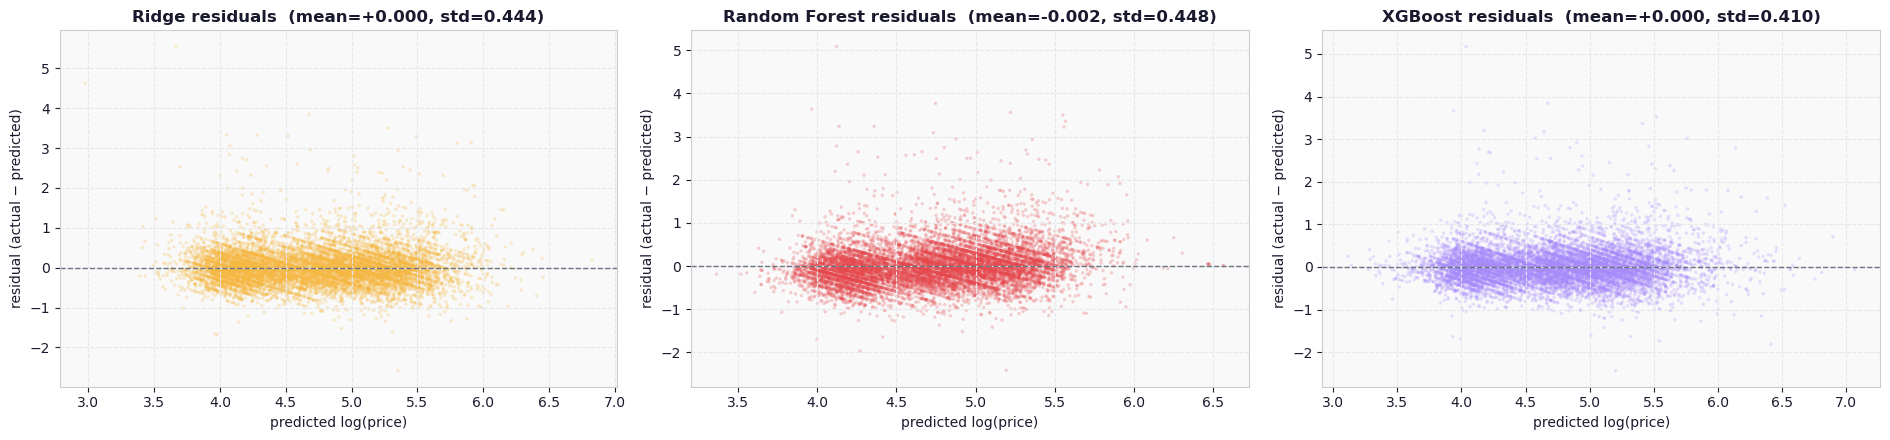

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(19, 4.5))

for ax, key, label, color in [
    (axes[0], "ridge", "Ridge",         ACCENT2),
    (axes[1], "rf",    "Random Forest", DANGER),
    (axes[2], "xgb",   "XGBoost",       ACCENT4),
]:
    residuals = y_test - predictions[key]
    ax.scatter(predictions[key], residuals, s=6, alpha=0.25, color=color, edgecolor="none")
    ax.axhline(0, color=MUTED, linestyle="--", linewidth=1)
    ax.set_xlabel("predicted log(price)")
    ax.set_ylabel("residual (actual − predicted)")
    ax.set_title(f"{label} residuals  (mean={residuals.mean():+.3f}, std={residuals.std():.3f})")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_residuals.png", dpi=130, bbox_inches="tight")
plt.show()


**Residual diagnostics** for Ridge (linear representative), RF, and XGBoost:

- x-axis: predicted log_price
- y-axis: residual = actual - predicted
- dashed line: zero reference

Residual plots reveal structure in the errors, beyond what a scatter plot shows. A key OLS assumption is homoscedasticity: residuals should scatter randomly around zero with no systematic shape.


Two key statistics in each panel title:

- **mean ≈ 0.000**: no systematic bias; the model is not consistently over- or under-predicting.
- **std ≈ 0.45**: residual standard deviation, equivalent to RMSE in log space.


## 10 · Top Features by Model

### Linear / Ridge / Lasso: Standardised Coefficients

Because features are standardised, the magnitude of each coefficient corresponds
directly to effect size per one-standard-deviation change in that feature.

What actually drives NYC Airbnb prices? We examine this from two angles: standardised linear model coefficients and tree-based feature importance.


In [20]:
# Linear model coefficient comparison
coef_df = pd.DataFrame({
    "feature": feat_names,
    "linear":  lr.coef_,
    "ridge":   ridge.coef_,
    "lasso":   lasso.coef_,
})
coef_df["abs_ridge"] = coef_df["ridge"].abs()
coef_top = coef_df.sort_values("abs_ridge", ascending=False).head(15)
print("Top 15 features by |Ridge coefficient|:")
print(coef_top[["feature", "linear", "ridge", "lasso"]].round(4).to_string(index=False))
coef_df.to_csv("data/linear_coefficients.csv", index=False)

Top 15 features by |Ridge coefficient|:
                      feature  linear   ridge   lasso
       room_type_Private room -0.3208 -0.3201 -0.3206
                nb_target_enc  0.2202  0.2191  0.2190
        room_type_Shared room -0.1522 -0.1519 -0.1519
neighbourhood_group_Manhattan  0.1170  0.1125  0.0998
 neighbourhood_group_Brooklyn  0.0980  0.0918  0.0763
             availability_365  0.0836  0.0833  0.0823
                bedroom_count  0.0780  0.0780  0.0778
                    kw_studio -0.0738 -0.0733 -0.0711
   neighbourhood_group_Queens  0.0710  0.0676  0.0582
               minimum_nights -0.0516 -0.0515 -0.0510
                   tfidf_pc26 -0.0382 -0.0381 -0.0379
                   tfidf_pc15 -0.0371 -0.0371 -0.0366
                    longitude -0.0355 -0.0361 -0.0353
                   tfidf_pc16  0.0321  0.0320  0.0307
                   tfidf_pc40  0.0272  0.0271  0.0268


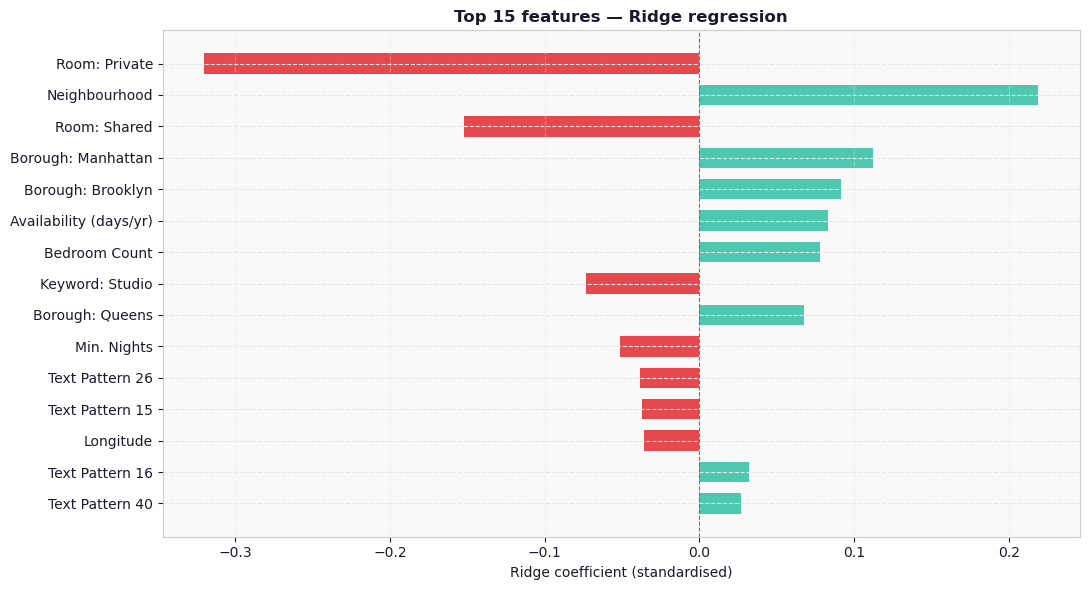

In [21]:
fig, ax = plt.subplots(figsize=(11, 6))
top15 = coef_top.iloc[::-1]
colors = [ACCENT3 if v > 0 else DANGER for v in top15["ridge"]]
labels = top15["feature"].map(pretty_name)
ax.barh(labels, top15["ridge"], color=colors, edgecolor="none", height=0.65)
ax.axvline(0, color=MUTED, linewidth=0.8, linestyle="--")
ax.set_xlabel("Ridge coefficient (standardised)")
ax.set_title("Top 15 features — Ridge regression")
ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_ridge_coefs.png", dpi=130, bbox_inches="tight")
plt.show()


Positive coefficients (price-increasing) shown in teal, negative (price-reducing) in red. Magnitude reflects the effect size per one-standard-deviation change in that feature.


### Random Forest: Feature Importance

In [22]:
rf_imp = pd.DataFrame({
    "feature": feat_names,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False)
print("Top 15 features by Random Forest importance:")
print(rf_imp.head(15).round(4).to_string(index=False))
rf_imp.to_csv("data/rf_feature_importance.csv", index=False)

Top 15 features by Random Forest importance:
                      feature  importance
       room_type_Private room      0.1623
                nb_target_enc      0.0812
                    longitude      0.0595
                    tfidf_pc5      0.0346
neighbourhood_group_Manhattan      0.0328
                     latitude      0.0277
                    tfidf_pc3      0.0232
                bedroom_count      0.0221
        room_type_Shared room      0.0199
                   tfidf_pc14      0.0194
                    tfidf_pc8      0.0176
                   tfidf_pc13      0.0137
             availability_365      0.0137
                    tfidf_pc6      0.0120
                    tfidf_pc2      0.0105


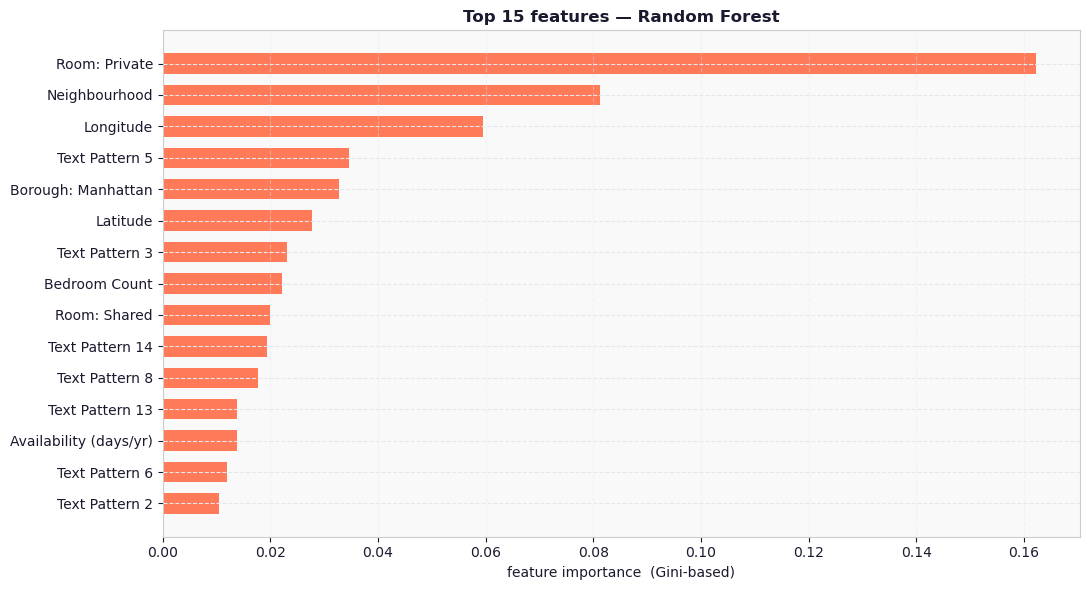

In [23]:
top15_rf = rf_imp.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(11, 6))
labels_rf = top15_rf["feature"].map(pretty_name)
ax.barh(labels_rf, top15_rf["importance"],
        color=ACCENT, edgecolor="none", height=0.65)
ax.set_xlabel("feature importance  (Gini-based)")
ax.set_title("Top 15 features — Random Forest")
ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_rf_importance.png", dpi=130, bbox_inches="tight")
plt.show()


### XGBoost: Feature Importance (Gain)


Top 15 features by XGBoost importance (gain):
                      feature  importance
       room_type_Private room      0.3821
        room_type_Shared room      0.0900
                nb_target_enc      0.0523
neighbourhood_group_Manhattan      0.0275
                    kw_studio      0.0269
                bedroom_count      0.0214
                    tfidf_pc5      0.0125
                   tfidf_pc14      0.0119
                      kw_cozy      0.0109
                    kw_luxury      0.0100
             availability_365      0.0089
                    longitude      0.0084
                   tfidf_pc30      0.0070
                     kw_suite      0.0064
                      kw_loft      0.0062


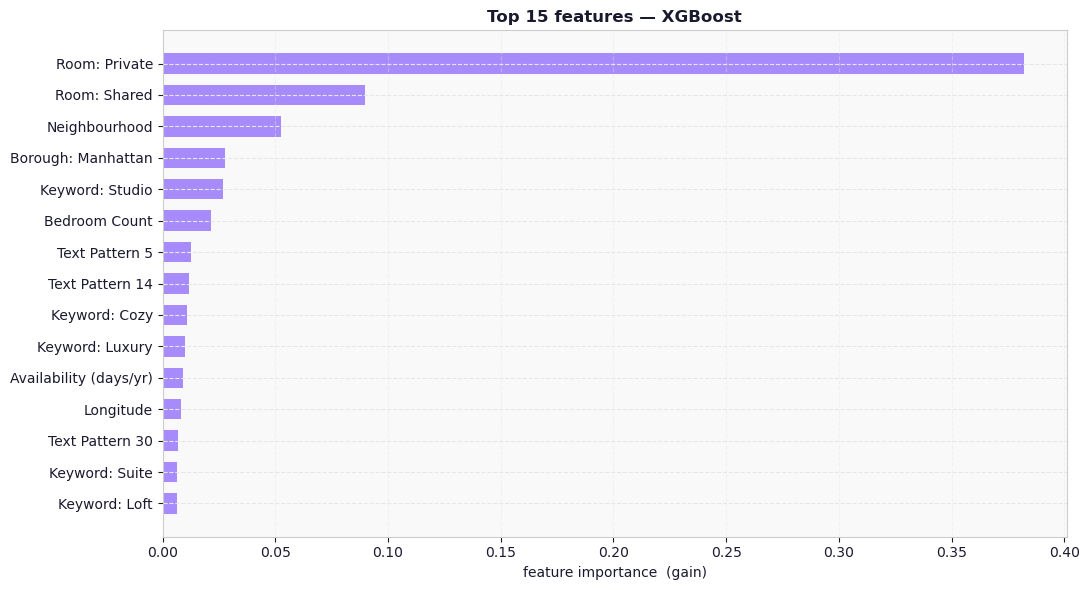

In [24]:
xgb_imp = pd.DataFrame({
    "feature":    feat_names,
    "importance": xgb_model.feature_importances_,
}).sort_values("importance", ascending=False)
print("Top 15 features by XGBoost importance (gain):")
print(xgb_imp.head(15).round(4).to_string(index=False))

top15_xgb = xgb_imp.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(11, 6))
labels_xgb = top15_xgb["feature"].map(pretty_name)
ax.barh(labels_xgb, top15_xgb["importance"],
        color=ACCENT4, edgecolor="none", height=0.65)
ax.set_xlabel("feature importance  (gain)")
ax.set_title("Top 15 features — XGBoost")
ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_xgb_importance.png", dpi=130, bbox_inches="tight")
plt.show()


- `room_type_Private room` alone accounts for 16.2% of the model's predictive power, making it the single dominant feature.
- The top 5 features together explain ~35% of the model's decisions.
- The remaining 65% is distributed across the other 151 features.


**Two fundamentally different algorithm families (linear models and tree ensembles) agree that room_type and neighbourhood are the dominant predictors.** This cross-model consensus strengthens confidence in the finding.


## 11 · Export Predictions

In [25]:
pred_df = pd.DataFrame({
    "y_test_log":      y_test,
    "y_test_dollars":  np.exp(y_test),
    "pred_linear_log": predictions["linear"],
    "pred_ridge_log":  predictions["ridge"],
    "pred_lasso_log":  predictions["lasso"],
    "pred_rf_log":     predictions["rf"],
    "pred_xgb_log":    predictions["xgb"],
    "pred_linear_$":   np.exp(predictions["linear"]),
    "pred_ridge_$":    np.exp(predictions["ridge"]),
    "pred_lasso_$":    np.exp(predictions["lasso"]),
    "pred_rf_$":       np.exp(predictions["rf"]),
    "pred_xgb_$":      np.exp(predictions["xgb"]),
})
pred_df.to_csv("data/test_predictions.csv", index=False)
print(f"Exported test_predictions.csv — shape: {pred_df.shape}")
pred_df.head()


Exported test_predictions.csv — shape: (9774, 12)


,y_test_log,y_test_dollars,pred_linear_log,pred_ridge_log,pred_lasso_log,pred_rf_log,pred_xgb_log,pred_linear_$,pred_ridge_$,pred_lasso_$,pred_rf_$,pred_xgb_$
0,3.806662,45.0,4.589471,4.592173,4.608419,4.834281,4.556605,98.442328,98.708727,100.325435,125.748176,95.259560
1,4.442651,85.0,5.082274,5.081540,5.084716,5.110056,5.139635,161.139992,161.021918,161.533998,165.679636,170.653397
2,5.257495,192.0,5.543105,5.542337,5.545732,5.284190,5.296361,255.470116,255.273949,256.141885,197.194365,199.609100
3,4.787492,120.0,4.877160,4.876256,4.864677,4.863615,4.862903,131.257324,131.138815,129.629100,129.491455,129.399261
4,5.247024,190.0,4.979895,4.978973,4.980228,4.856227,5.004117,145.459178,145.325072,145.507599,128.538374,149.025360


This table is the per-listing scorecard for all 9,774 test-set listings. Each row is one listing; each column is one model's prediction in both log and dollar space.


## 12 · Summary & Interpretation

### Performance ranking (test R²)

The five models span a clear complexity ladder:

1. **Ridge ≈ Lasso ≈ Linear.** With n = 39k training rows and p = 156 features,
   OLS is already well-posed. Regularisation only helps when p approaches n or
   features are highly collinear. Neither holds here (TF-IDF was decorrelated via PCA).

2. **Lasso's CV-optimal α is very small** (≈ 4e-4) and it keeps almost all features.
   This is the optimiser telling us: don't shrink, you don't need to.

3. **Random Forest scores slightly *below* the linear models.** The target
   (`log_price`) was already linearised in the EDA, removing the main non-linearity
   RF excels at. RF also struggles with the 128 sparse TF-IDF PCs.

4. **XGBoost**: sequential residual correction typically recovers a small margin
   over RF. Even so, all models are bounded by the same data ceiling (~60% R²):
   the remaining 40% reflects unmeasured factors (photo quality, amenities, host responsiveness).

### What drives NYC Airbnb prices: Final Picture

Across all five models, the top predictors agree:

- **Room type** (Private / Shared vs Entire home): the single strongest predictor
- **Neighbourhood**: captured by the target-encoded column and borough one-hots
- **Location coordinates**: longitude's pull toward Manhattan is substantial
- **Listing description**: `bedroom_count` plus a few TF-IDF components carry real signal
